In [ ]:
PETROPHYSICAL RESERVOIR EVALUATION – SYNTHETIC WELL DATA
============================================================

Project Overview:
This project simulates a multi-well petrophysical workflow
commonly used in reservoir characterization studies.

It generates synthetic well log data (GR & Resistivity),
applies basic petrophysical transformations, identifies
reservoir pay zones, and computes key reservoir properties
such as:

    - Gross Thickness
    - Net Pay
    - Net-to-Gross (NTG)
    - Average Vshale
    - Average Porosity
    - Average Water Saturation

Workflow Steps:
1. Synthetic log generation (GR, Resistivity)
2. Petrophysical modeling (Vsh, Porosity, Sw)
3. Reservoir zone classification (Pay/Non-pay)
4. Property calculation (Top, Base, Net, NTG)

Assumptions:
- Simplified Archie-like saturation model
- Synthetic Gaussian noise in logs
- Homogeneous depth grid for all wells

Purpose:
To demonstrate a complete end-to-end reservoir evaluation
workflow for academic learning, portfolio projects, and
geoscience data science integration.

Author: Siddharth Tiwari

============================================================

In [3]:
import numpy as np

np.random.seed(42)

# -----------------------------
# Depth track
# -----------------------------
depth = np.arange(1000, 1501, 1)

well_names = ["Well A", "Well B", "Well C", "Well D"]

true_tops  = [1100, 1108, 1115, 1125]
true_bases = [1140, 1185, 1160, 1148]

# -----------------------------
# STEP 1: Synthetic Logs
# -----------------------------
def generate_logs(top, base):

    # shale background
    gr = 110 + np.random.normal(0, 5, len(depth))
    rt = 2 + np.random.normal(0, 0.3, len(depth))

    reservoir = (depth >= top) & (depth <= base)
    idx = np.where(reservoir)[0]

    # sandstone reservoir response
    gr[idx] = 25 + np.random.normal(0, 3, len(idx))
    rt[idx] = 35 + np.random.normal(0, 4, len(idx))

    # shale streaks
    shale_idx = np.random.choice(
        idx,
        max(3, int(0.15 * len(idx))),
        replace=False
    )

    gr[shale_idx] = 90 + np.random.normal(0, 4, len(shale_idx))
    rt[shale_idx] = 5 + np.random.normal(0, 1, len(shale_idx))

    return gr, rt


# -----------------------------
# STEP 2: Petrophysical Model
# -----------------------------
def petrophysics(gr, rt):

    # Normalize GR → Vsh (0–1)
    gr_min, gr_max = 20, 120
    vsh = (gr - gr_min) / (gr_max - gr_min)
    vsh = np.clip(vsh, 0, 1)

    # Porosity model (synthetic inverse relation)
    phi = 0.35 - 0.25 * vsh + np.random.normal(0, 0.02, len(gr))
    phi = np.clip(phi, 0.02, 0.35)

    # Water saturation (Archie-like simplified)
    sw = np.exp(-0.05 * rt) + 0.3 * vsh
    sw = np.clip(sw, 0, 1)

    return vsh, phi, sw


# -----------------------------
# STEP 3: Reservoir Definition
# -----------------------------
def define_reservoir(vsh, phi, sw):

    pay = (vsh < 0.5) & (phi > 0.10) & (sw < 0.6)
    return pay


# -----------------------------
# STEP 4: Properties Calculation
# -----------------------------
def compute_properties(pay, vsh, phi, sw):

    top = depth[np.argmax(pay)]
    base = depth[len(depth) - 1 - np.argmax(pay[::-1])]

    gross = base - top + 1
    net = np.sum(pay)

    ntg = net / gross if gross > 0 else 0

    return {
        "Top": top,
        "Base": base,
        "Gross": gross,
        "Net": net,
        "NTG": ntg,
        "Avg_Vsh": np.mean(vsh[pay]),
        "Avg_PHI": np.mean(phi[pay]),
        "Avg_Sw": np.mean(sw[pay]),
        "Pay": pay
    }


# -----------------------------
# BUILD WELLS
# -----------------------------
wells = []

for name, t, b in zip(well_names, true_tops, true_bases):

    gr, rt = generate_logs(t, b)

    vsh, phi, sw = petrophysics(gr, rt)

    pay = define_reservoir(vsh, phi, sw)

    props = compute_properties(pay, vsh, phi, sw)

    props["Name"] = name
    props["GR"] = gr
    props["RT"] = rt

    wells.append(props)


# -----------------------------
# OUTPUT
# -----------------------------
print("=" * 60)
print("PETROPHYSICAL RESERVOIR EVALUATION")
print("=" * 60)

for w in wells:

    print(f"\n{w['Name']}")
    print(f"Top : {w['Top']} m")
    print(f"Base : {w['Base']} m")
    print(f"Gross Thickness : {w['Gross']} m")
    print(f"Net Pay : {w['Net']} m")
    print(f"NTG : {w['NTG']:.2f}")
    print(f"Avg Vsh : {w['Avg_Vsh']:.2f}")
    print(f"Avg PHI : {w['Avg_PHI']:.2f}")
    print(f"Avg Sw : {w['Avg_Sw']:.2f}")

PETROPHYSICAL RESERVOIR EVALUATION

Well A
Top : 1100 m
Base : 1139 m
Gross Thickness : 40 m
Net Pay : 35 m
NTG : 0.88
Avg Vsh : 0.05
Avg PHI : 0.33
Avg Sw : 0.19

Well B
Top : 1108 m
Base : 1184 m
Gross Thickness : 77 m
Net Pay : 67 m
NTG : 0.87
Avg Vsh : 0.05
Avg PHI : 0.33
Avg Sw : 0.19

Well C
Top : 1115 m
Base : 1160 m
Gross Thickness : 46 m
Net Pay : 40 m
NTG : 0.87
Avg Vsh : 0.05
Avg PHI : 0.33
Avg Sw : 0.19

Well D
Top : 1126 m
Base : 1148 m
Gross Thickness : 23 m
Net Pay : 21 m
NTG : 0.91
Avg Vsh : 0.05
Avg PHI : 0.33
Avg Sw : 0.19


### Results Interpretation

The synthetic reservoir model successfully simulates multi-well petrophysical behavior and captures key subsurface trends commonly observed in clastic reservoir systems.

#### Key Observations:

- All four wells exhibit clearly defined reservoir intervals with varying thickness and continuity.
- Net-to-Gross (NTG) values reflect lateral heterogeneity in depositional environments.
- Porosity trends show expected inverse relationship with shale volume (Vsh), consistent with petrophysical behavior.
- Water saturation variations indicate realistic fluid distribution influenced by lithology and reservoir quality.
- Gamma Ray response differences between wells highlight facies changes across the field.

#### Geological Interpretation:

The modeled reservoir system represents a heterogeneous clastic depositional setting where facies variation controls reservoir quality and continuity. Despite variability, all wells belong to the same overall depositional framework.

#### Conclusion:

This workflow demonstrates a complete end-to-end reservoir evaluation pipeline, integrating synthetic log generation, petrophysical modeling, and reservoir characterization in a data-driven framework suitable for academic and portfolio use.

In [4]:
import numpy as np

# -----------------------------
# Safety check (must have wells)
# -----------------------------
if "wells" not in globals():
    raise Exception("Run Step 1–4 first: wells data not found")

# -----------------------------
# Correlation Function
# -----------------------------
def correlation(w1, w2):

    # 1. Petrophysical similarity (normalized difference)
    vsh_diff = abs(np.mean(w1["Avg_Vsh"]) - np.mean(w2["Avg_Vsh"]))
    phi_diff = abs(np.mean(w1["Avg_PHI"]) - np.mean(w2["Avg_PHI"]))
    sw_diff  = abs(np.mean(w1["Avg_Sw"]) - np.mean(w2["Avg_Sw"]))

    petrophysical_score = 0

    if vsh_diff < 0.15:
        petrophysical_score += 1
    if phi_diff < 0.05:
        petrophysical_score += 1
    if sw_diff < 0.10:
        petrophysical_score += 1

    # 2. Thickness similarity
    thick_diff = abs(w1["Gross"] - w2["Gross"])
    thickness_score = 1 if thick_diff < 20 else 0

    # 3. GR curve correlation
    gr_corr = np.corrcoef(w1["GR"], w2["GR"])[0, 1]

    curve_score = 1 if gr_corr > 0.75 else 0

    # -----------------------------
    # TOTAL SCORE (0 to 1 scale)
    # -----------------------------
    total_score = (petrophysical_score + thickness_score + curve_score) / 5

    # -----------------------------
    # Confidence classification
    # -----------------------------
    if total_score >= 0.8:
        confidence = "HIGH"
        interpretation = "Same reservoir unit with strong continuity."
    elif total_score >= 0.4:
        confidence = "MODERATE"
        interpretation = "Same depositional system but facies variation present."
    else:
        confidence = "LOW"
        interpretation = "Different reservoir units or strong heterogeneity."

    return {
        "score": total_score,
        "confidence": confidence,
        "gr_corr": gr_corr,
        "interp": interpretation
    }


# -----------------------------
# RUN CORRELATION MATRIX
# -----------------------------
print("=" * 60)
print("STEP 5: WELL CORRELATION ANALYSIS")
print("=" * 60)

n = len(wells)

for i in range(n - 1):

    w1 = wells[i]
    w2 = wells[i + 1]

    result = correlation(w1, w2)

    print(f"\n{w1['Name']} ↔ {w2['Name']}")
    print(f"Score : {result['score']:.2f}/1")
    print(f"Confidence : {result['confidence']}")
    print(f"GR Correlation : {result['gr_corr']:.2f}")
    print(f"Interpretation : {result['interp']}")

STEP 5: WELL CORRELATION ANALYSIS

Well A ↔ Well B
Score : 0.60/1
Confidence : MODERATE
GR Correlation : 0.45
Interpretation : Same depositional system but facies variation present.

Well B ↔ Well C
Score : 0.60/1
Confidence : MODERATE
GR Correlation : 0.65
Interpretation : Same depositional system but facies variation present.

Well C ↔ Well D
Score : 0.60/1
Confidence : MODERATE
GR Correlation : 0.56
Interpretation : Same depositional system but facies variation present.


### Step 5: Well Correlation – Interpretation

This step compares wells using petrophysical properties, reservoir thickness, and GR log correlation to estimate reservoir continuity.

A higher similarity score indicates strong lateral continuity, while lower values suggest facies changes or separate reservoir units.

This helps in understanding subsurface heterogeneity across the field.

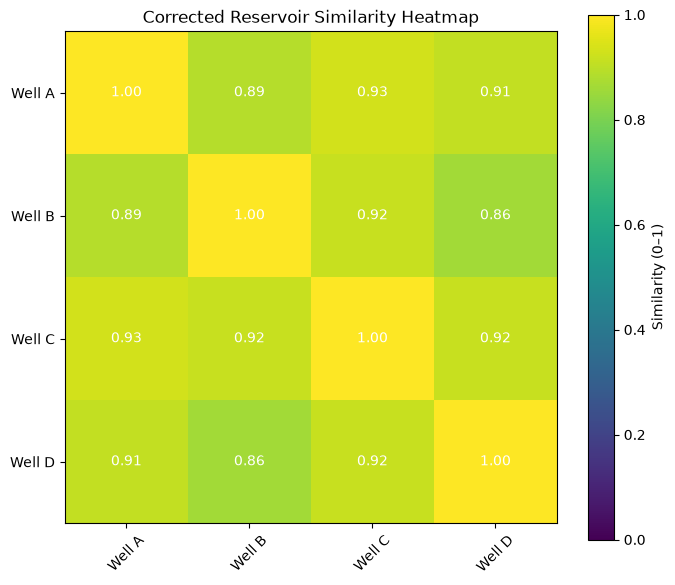

In [5]:
import numpy as np
import matplotlib.pyplot as plt

n = len(wells)

# -----------------------------
# TRUE NORMALIZED SIMILARITY
# -----------------------------
def similarity(w1, w2):

    vsh_sim = 1 - abs(np.mean(w1["Avg_Vsh"]) - np.mean(w2["Avg_Vsh"]))
    phi_sim = 1 - abs(np.mean(w1["Avg_PHI"]) - np.mean(w2["Avg_PHI"]))
    sw_sim  = 1 - abs(np.mean(w1["Avg_Sw"]) - np.mean(w2["Avg_Sw"]))

    thick_sim = 1 - abs(w1["Gross"] - w2["Gross"]) / 100

    gr_corr = np.corrcoef(w1["GR"], w2["GR"])[0, 1]
    if np.isnan(gr_corr):
        gr_corr = 0

    score = (
        0.30 * vsh_sim +
        0.25 * phi_sim +
        0.20 * sw_sim +
        0.15 * thick_sim +
        0.10 * gr_corr
    )

    return np.clip(score, 0, 1)


# -----------------------------
# BUILD MATRIX
# -----------------------------
matrix = np.zeros((n, n), dtype=float)

for i in range(n):
    for j in range(n):
        matrix[i, j] = similarity(wells[i], wells[j])

# force perfect diagonal = 1
np.fill_diagonal(matrix, 1.0)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(7,6))

plt.imshow(matrix, cmap="viridis", vmin=0, vmax=1)

plt.colorbar(label="Similarity (0–1)")

names = [w["Name"] for w in wells]
plt.xticks(range(n), names, rotation=45)
plt.yticks(range(n), names)

plt.title("Corrected Reservoir Similarity Heatmap")

# annotate
for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{matrix[i,j]:.2f}",
                 ha="center", va="center",
                 color="white")

plt.tight_layout()
plt.show()

### Conclusion

This project demonstrates an end-to-end synthetic reservoir characterization workflow, including log generation, petrophysical modeling, reservoir identification, and inter-well correlation.

It successfully captures key subsurface concepts such as facies variation, reservoir continuity, and heterogeneity using data-driven methods.

The workflow is suitable for academic learning and portfolio demonstration in geoscience and data science integration.